<a href="https://colab.research.google.com/github/HimathDissa/NorthStar-Analytics-CP60056E/blob/main/notebooks/NorthStar_R_Statistical_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Install & Load Packages

pkgs <- c("ggplot2", "dplyr", "tidyr", "scales", "corrplot", "lubridate",
          "ggcorrplot", "gridExtra", "RColorBrewer")
for (p in pkgs) {
  if (!require(p, character.only = TRUE)) install.packages(p, quiet = TRUE)
  library(p, character.only = TRUE)
}

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: tidyr

Loading required package: scales

Loading required package: corrplot

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘corrplot’”
corrplot 0.95 loaded

Loading required package: lubridate


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Loading required package: ggcorrplot

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘ggcorrplot’”
also installing the dependencies ‘plyr’, ‘reshape2’


Loading required package: gridExtra

Warning message in librar

In [ ]:
#1. Load All Dataset

customers  <- read.csv("/content/customers.csv")
orders     <- read.csv("/content/orders.csv")
deliveries <- read.csv("/content/deliveries.csv")
drivers    <- read.csv("/content/drivers.csv")
vehicles   <- read.csv("/content/vehicles.csv")
hubs       <- read.csv("/content/hubs.csv")
incidents  <- read.csv("/content/incidents.csv")
complaints <- read.csv("/content/complaints.csv")

cat("All datasets loaded!\n")

All datasets loaded!


In [ ]:
#2. Data Cleaning & Feature Engineering

clean_zone <- function(x) toupper(trimws(x))
orders$pickup_zone     <- clean_zone(orders$pickup_zone)
orders$dropoff_zone    <- clean_zone(orders$dropoff_zone)
customers$home_zone    <- clean_zone(customers$home_zone)
drivers$base_zone      <- clean_zone(drivers$base_zone)
vehicles$assigned_zone <- clean_zone(vehicles$assigned_zone)

# Parse datetime columns
deliveries$dispatch_time          <- as.POSIXct(deliveries$dispatch_time,          format = "%Y-%m-%d %H:%M:%S")
deliveries$delivery_completed_at  <- as.POSIXct(deliveries$delivery_completed_at,  format = "%Y-%m-%d %H:%M:%S")
orders$order_created_at           <- as.POSIXct(orders$order_created_at,           format = "%Y-%m-%d %H:%M:%S")

# Feature: actual delivery duration in hours
deliveries$actual_duration_hrs <- as.numeric(
  difftime(deliveries$delivery_completed_at, deliveries$dispatch_time, units = "hours")
)
# Remove negative durations (data anomalies) and extreme outliers
deliveries$actual_duration_hrs[deliveries$actual_duration_hrs < 0]  <- NA
deliveries$actual_duration_hrs[deliveries$actual_duration_hrs > 72] <- NA

# Feature: order month-year for trend analysis
orders$order_month <- format(orders$order_created_at, "%Y-%m")

# Merge master analytical table
master <- deliveries %>%
  left_join(orders,    by = "order_id") %>%
  left_join(drivers,   by = "driver_id") %>%
  left_join(vehicles,  by = "vehicle_id") %>%
  left_join(customers, by = "customer_id")

cat("Master table created:", nrow(master), "rows\n\n")

Master table created: 950 rows



In [ ]:
# Analysis 1 - Gives a full statical profile of key numeric variables


cat("=== ANALYSIS 1: Descriptive Statistics ===\n")

numeric_vars <- master %>%
  select(customer_rating_post_delivery, route_distance_km, fuel_or_charge_cost,
         manual_route_override_count, actual_duration_hrs,
         order_value, loyalty_score, app_engagement_score,
         driver_rating, training_score, years_experience, battery_health_pct)

desc_stats <- data.frame(
  Variable = names(numeric_vars),
  N        = sapply(numeric_vars, function(x) sum(!is.na(x))),
  Mean     = round(sapply(numeric_vars, mean,   na.rm = TRUE), 2),
  Median   = round(sapply(numeric_vars, median, na.rm = TRUE), 2),
  SD       = round(sapply(numeric_vars, sd,     na.rm = TRUE), 2),
  Min      = round(sapply(numeric_vars, min,    na.rm = TRUE), 2),
  Max      = round(sapply(numeric_vars, max,    na.rm = TRUE), 2)
)
print(desc_stats)
cat("\n")

=== ANALYSIS 1: Descriptive Statistics ===
                                                   Variable   N  Mean Median
customer_rating_post_delivery customer_rating_post_delivery 936  3.86   4.04
route_distance_km                         route_distance_km 950 13.91  12.84
fuel_or_charge_cost                     fuel_or_charge_cost 950 12.84  12.64
manual_route_override_count     manual_route_override_count 950  0.97   1.00
actual_duration_hrs                     actual_duration_hrs 867 10.32   7.91
order_value                                     order_value 950 91.86  77.17
loyalty_score                                 loyalty_score 920 59.84  59.00
app_engagement_score                   app_engagement_score 950 58.05  59.00
driver_rating                                 driver_rating 950  4.16   4.17
training_score                               training_score 910 74.62  74.30
years_experience                           years_experience 950  8.26   9.00
battery_health_pct               

=== ANALYSIS 2: Delivery Status by Service Type ===
# A tibble: 15 × 4
# Groups:   service_type [5]
   service_type delivery_status count   pct
   <chr>        <chr>           <int> <dbl>
 1 Business     Delayed            28  22.2
 2 Business     Failed             25  19.8
 3 Business     OnTime             73  57.9
 4 Medical      Delayed            22  20.4
 5 Medical      Failed             16  14.8
 6 Medical      OnTime             70  64.8
 7 Parcel       Delayed            49  21.3
 8 Parcel       Failed             25  10.9
 9 Parcel       OnTime            156  67.8
10 Passenger    Delayed            53  20.2
11 Passenger    Failed             38  14.5
12 Passenger    OnTime            171  65.3
13 Retail       Delayed            50  22.3
14 Retail       Failed             28  12.5
15 Retail       OnTime            146  65.2


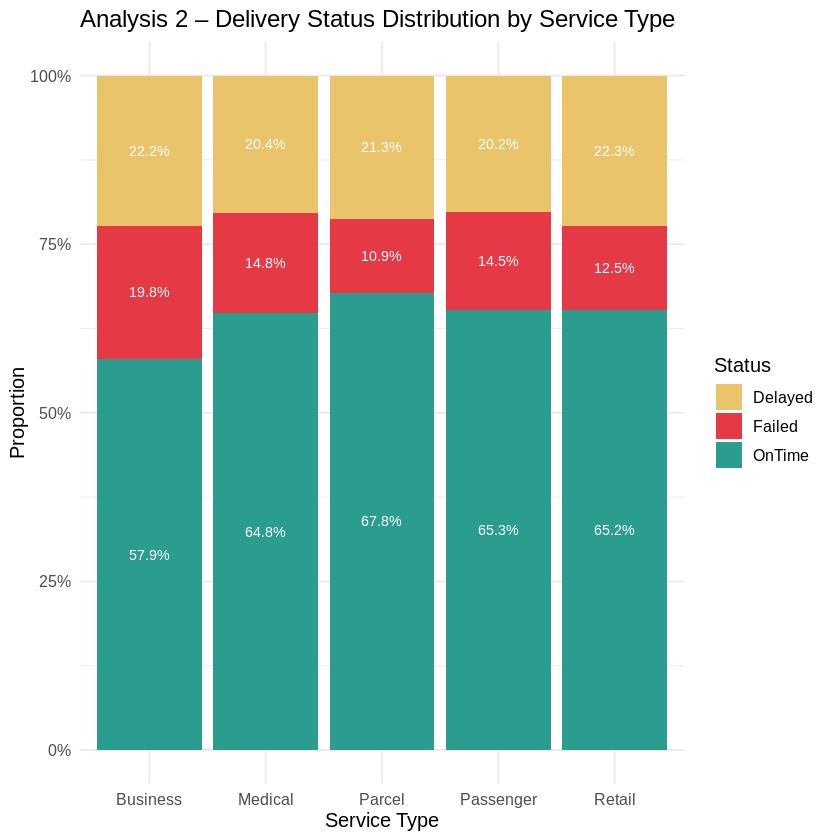

In [ ]:
#Analysis 2 - Delivery Status Distribution by Service Type

cat("=== ANALYSIS 2: Delivery Status by Service Type ===\n")

status_service <- master %>%
  filter(!is.na(delivery_status), !is.na(service_type)) %>%
  group_by(service_type, delivery_status) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(service_type) %>%
  mutate(pct = round(100 * count / sum(count), 1))

print(status_service)

ggplot(status_service, aes(x = service_type, y = pct, fill = delivery_status)) +
  geom_col(position = "fill") +
  geom_text(aes(label = paste0(pct, "%")),
            position = position_fill(vjust = 0.5), size = 3, colour = "white") +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = c("OnTime" = "#2a9d8f", "Delayed" = "#e9c46a", "Failed" = "#e63946")) +
  labs(title = "Analysis 2 – Delivery Status Distribution by Service Type",
       x = "Service Type", y = "Proportion", fill = "Status") +
  theme_minimal(base_size = 12)

=== ANALYSIS 3: Correlation Matrix ===
Correlation matrix (key pairs):
                              customer_rating_post_delivery route_distance_km
customer_rating_post_delivery                          1.00              0.03
route_distance_km                                      0.03              1.00
fuel_or_charge_cost                                   -0.07              0.54
manual_route_override_count                           -0.07              0.19
actual_duration_hrs                                   -0.29              0.03
driver_rating                                          0.12              0.01
training_score                                        -0.01             -0.09
years_experience                                      -0.06             -0.04
battery_health_pct                                    -0.02              0.01
loyalty_score                                          0.01              0.04
                              fuel_or_charge_cost manual_route_override

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>.”


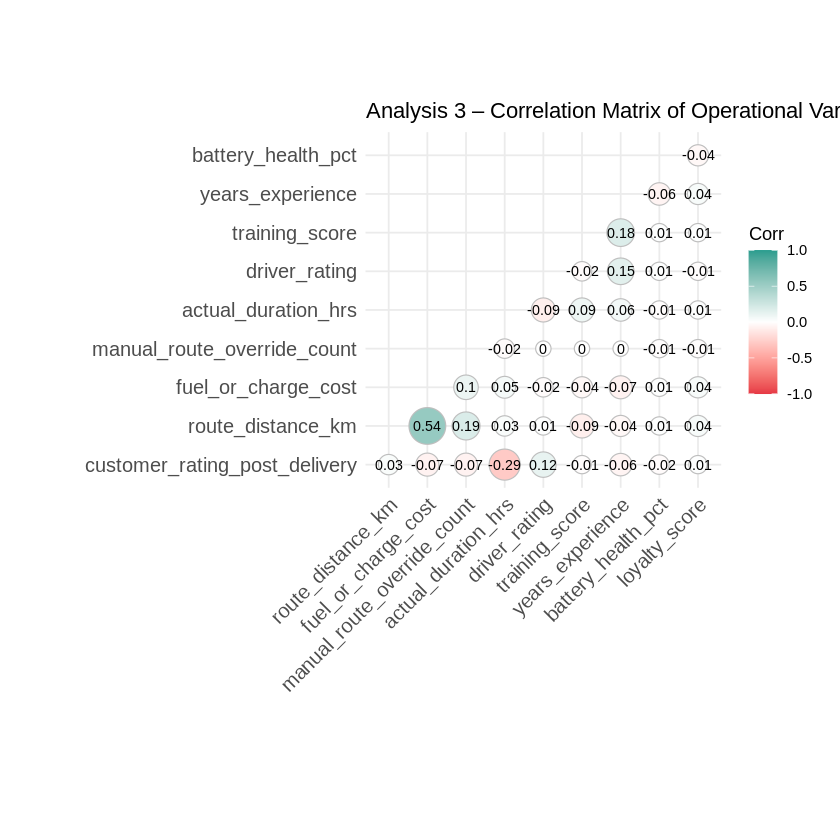

In [ ]:
# ANALYSIS 3 – Correlation Matrix of Key Operational Variables

cat("=== ANALYSIS 3: Correlation Matrix ===\n")

corr_data <- master %>%
  select(customer_rating_post_delivery, route_distance_km,
         fuel_or_charge_cost, manual_route_override_count,
         actual_duration_hrs, driver_rating, training_score,
         years_experience, battery_health_pct, loyalty_score) %>%
  filter(complete.cases(.))

corr_matrix <- round(cor(corr_data), 2)
cat("Correlation matrix (key pairs):\n")
print(corr_matrix)

ggcorrplot(corr_matrix,
           method   = "circle",
           type     = "lower",
           lab      = TRUE,
           lab_size = 3,
           colors   = c("#e63946", "white", "#2a9d8f"),
           title    = "Analysis 3 – Correlation Matrix of Operational Variables",
           ggtheme  = theme_minimal(base_size = 11))

=== ANALYSIS 4: Rating Distribution by Delivery Status ===
# A tibble: 3 × 5
  delivery_status     n mean_rating median_rating sd_rating
  <chr>           <int>       <dbl>         <dbl>     <dbl>
1 Delayed           197        3.11          3.2       0.94
2 Failed            131        3.05          3.03      0.88
3 OnTime            608        4.28          4.32      0.53

ANOVA – Rating vs Delivery Status:
                 Df Sum Sq Mean Sq F value Pr(>F)    
delivery_status   2  304.4  152.18     320 <2e-16 ***
Residuals       933  443.6    0.48                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


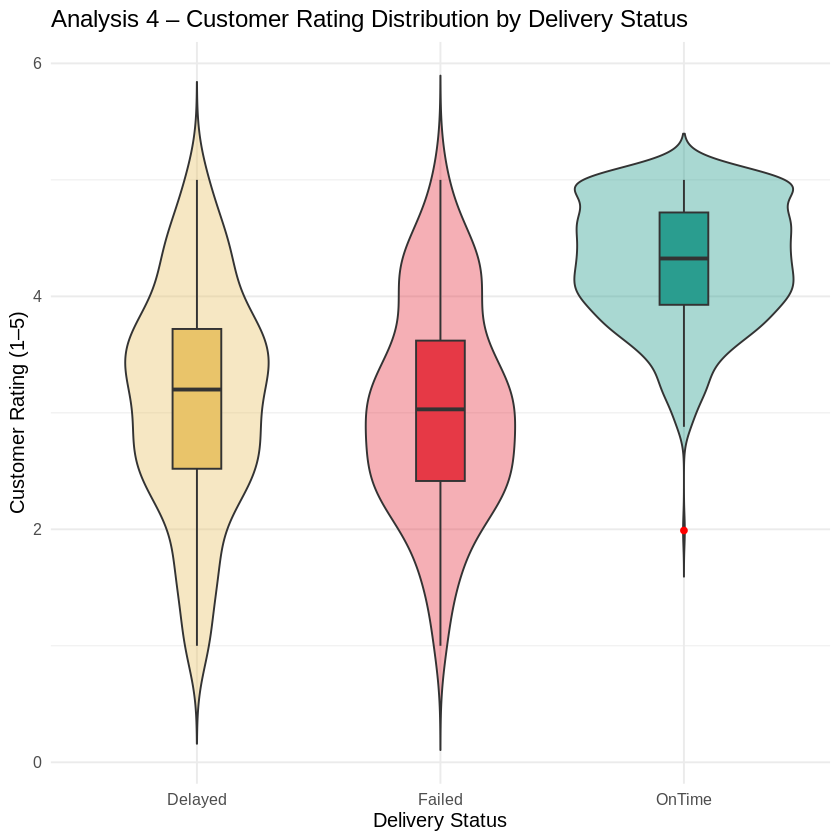

In [ ]:
# ANALYSIS 4 – Customer Rating Distribution by Delivery Status

cat("=== ANALYSIS 4: Rating Distribution by Delivery Status ===\n")

rating_stats <- master %>%
  filter(!is.na(delivery_status), !is.na(customer_rating_post_delivery)) %>%
  group_by(delivery_status) %>%
  summarise(
    n       = n(),
    mean_rating   = round(mean(customer_rating_post_delivery), 2),
    median_rating = round(median(customer_rating_post_delivery), 2),
    sd_rating     = round(sd(customer_rating_post_delivery), 2),
    .groups = "drop"
  )
print(rating_stats)

# Box + violin combined
master %>%
  filter(!is.na(delivery_status), !is.na(customer_rating_post_delivery)) %>%
  ggplot(aes(x = delivery_status, y = customer_rating_post_delivery,
             fill = delivery_status)) +
  geom_violin(alpha = 0.4, trim = FALSE) +
  geom_boxplot(width = 0.2, outlier.colour = "red", outlier.size = 1.5) +
  scale_fill_manual(values = c("OnTime" = "#2a9d8f", "Delayed" = "#e9c46a", "Failed" = "#e63946")) +
  labs(title = "Analysis 4 – Customer Rating Distribution by Delivery Status",
       x = "Delivery Status", y = "Customer Rating (1–5)") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none")

# One-way ANOVA to test if means differ significantly
anova_result <- aov(customer_rating_post_delivery ~ delivery_status,
                    data = master %>% filter(!is.na(customer_rating_post_delivery)))
cat("\nANOVA – Rating vs Delivery Status:\n")
print(summary(anova_result))

=== ANALYSIS 5: Driver Profile vs Delivery Outcomes ===
Driver performance summary:
 years_experience training_score  driver_rating    failure_rate   
 Min.   : 1.00    Min.   :40.60   Min.   :3.150   Min.   :  0.00  
 1st Qu.: 5.00    1st Qu.:68.60   1st Qu.:3.910   1st Qu.: 23.60  
 Median : 9.00    Median :74.60   Median :4.170   Median : 36.40  
 Mean   : 8.47    Mean   :74.78   Mean   :4.171   Mean   : 36.48  
 3rd Qu.:12.00    3rd Qu.:82.70   3rd Qu.:4.475   3rd Qu.: 50.00  
 Max.   :15.00    Max.   :99.00   Max.   :5.000   Max.   :100.00  
                  NAs    :6                                       


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”



Correlation: training_score vs failure_rate = 0.081 
Correlation: years_experience vs failure_rate = 0.237 



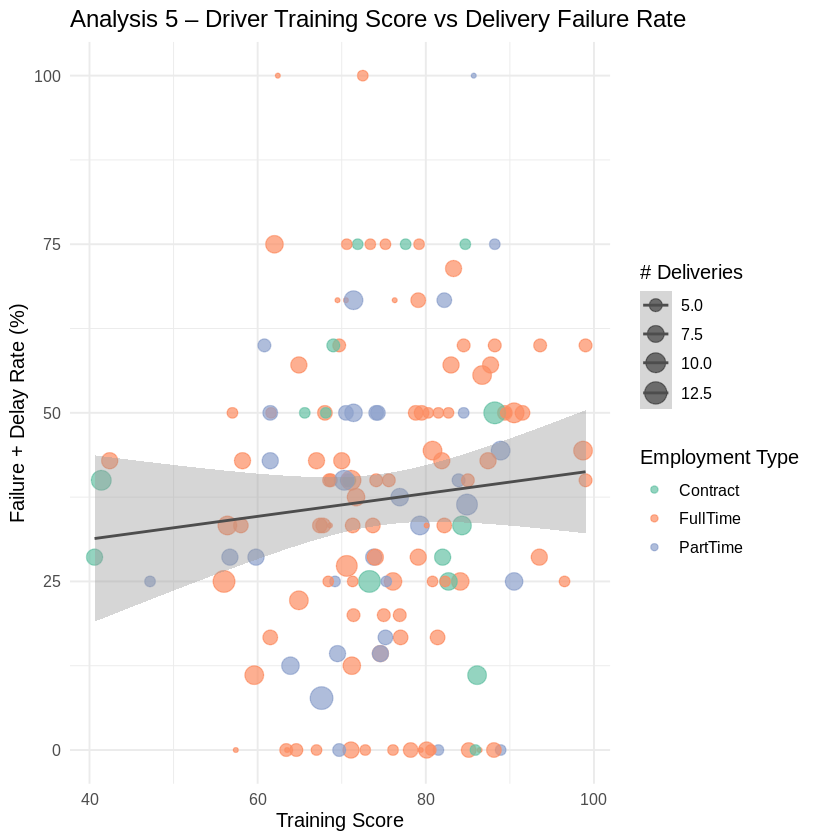

In [ ]:
# ANALYSIS 5 – Driver Experience & Training vs Delivery Failure Rate

cat("=== ANALYSIS 5: Driver Profile vs Delivery Outcomes ===\n")

driver_perf <- master %>%
  filter(!is.na(driver_id), !is.na(delivery_status)) %>%
  group_by(driver_id, employment_type, years_experience, training_score, driver_rating) %>%
  summarise(
    total        = n(),
    failed       = sum(delivery_status == "Failed",  na.rm = TRUE),
    delayed      = sum(delivery_status == "Delayed", na.rm = TRUE),
    failure_rate = round(100 * (failed + delayed) / total, 1),
    avg_rating   = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  filter(total >= 3)

cat("Driver performance summary:\n")
print(summary(driver_perf[, c("years_experience","training_score","driver_rating","failure_rate")]))

# Scatter: training score vs failure rate, coloured by employment type
ggplot(driver_perf, aes(x = training_score, y = failure_rate,
                        colour = employment_type, size = total)) +
  geom_point(alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE, colour = "grey30", linewidth = 0.8) +
  scale_colour_brewer(palette = "Set2") +
  labs(title = "Analysis 5 – Driver Training Score vs Delivery Failure Rate",
       x = "Training Score", y = "Failure + Delay Rate (%)",
       colour = "Employment Type", size = "# Deliveries") +
  theme_minimal(base_size = 12)

# Correlation: training score vs failure rate
cat("\nCorrelation: training_score vs failure_rate =",
    round(cor(driver_perf$training_score, driver_perf$failure_rate, use = "complete.obs"), 3), "\n")
cat("Correlation: years_experience vs failure_rate =",
    round(cor(driver_perf$years_experience, driver_perf$failure_rate, use = "complete.obs"), 3), "\n\n")

=== ANALYSIS 6: Monthly Order Volume & Revenue Trend ===
# A tibble: 24 × 3
   order_month total_orders total_revenue
   <chr>              <int>         <dbl>
 1 2024-01               56         5271.
 2 2024-02               59         5233.
 3 2024-03               65         5737.
 4 2024-04               46         4161.
 5 2024-05               45         4520.
 6 2024-06               60         6263.
 7 2024-07               45         4150.
 8 2024-08               56         5430.
 9 2024-09               60         4952.
10 2024-10               44         3706.
# ℹ 14 more rows


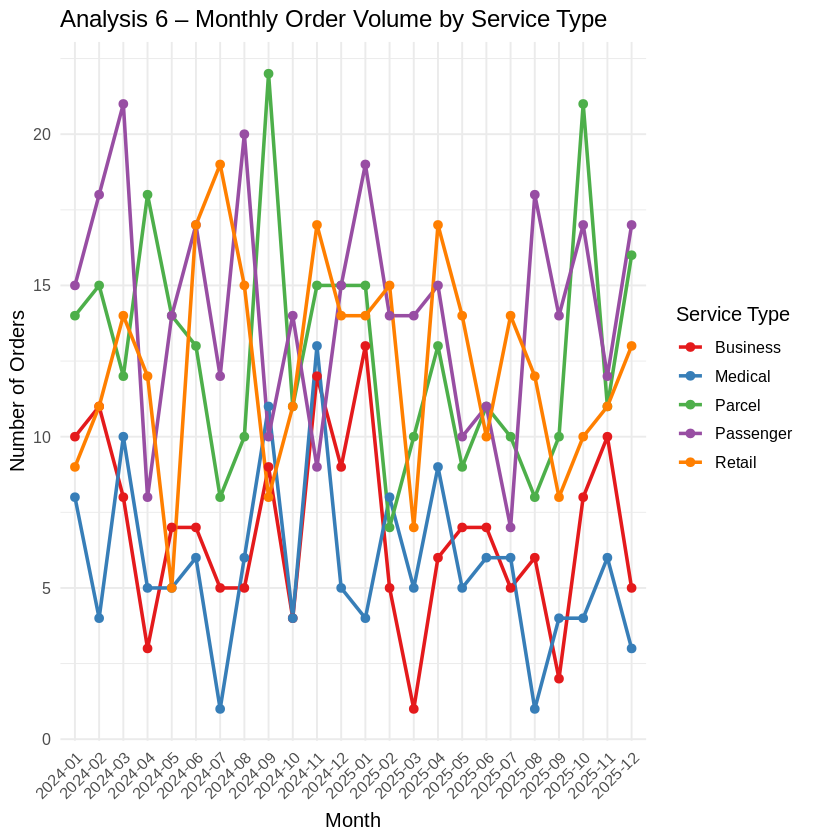

In [ ]:
# ANALYSIS 6 – Monthly Order Volume & Revenue Trend

cat("=== ANALYSIS 6: Monthly Order Volume & Revenue Trend ===\n")

monthly_trend <- orders %>%
  filter(!is.na(order_month)) %>%
  group_by(order_month, service_type) %>%
  summarise(
    order_count   = n(),
    total_revenue = round(sum(order_value, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  arrange(order_month)

# Overall monthly totals
monthly_total <- monthly_trend %>%
  group_by(order_month) %>%
  summarise(total_orders = sum(order_count),
            total_revenue = sum(total_revenue), .groups = "drop")

print(monthly_total)

# Line chart: order volume by service type over time
ggplot(monthly_trend, aes(x = order_month, y = order_count,
                          colour = service_type, group = service_type)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_colour_brewer(palette = "Set1") +
  labs(title = "Analysis 6 – Monthly Order Volume by Service Type",
       x = "Month", y = "Number of Orders", colour = "Service Type") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

=== ANALYSIS 7: Battery Health vs Charge Cost ===
Correlation: battery_health_pct vs avg_charge_cost = -0.038 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


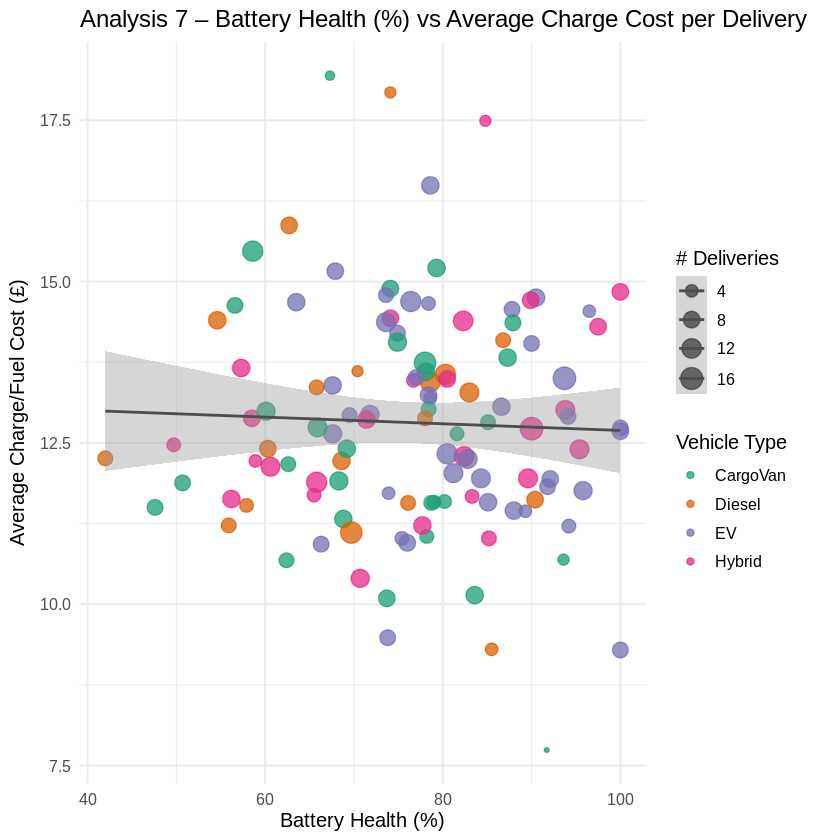

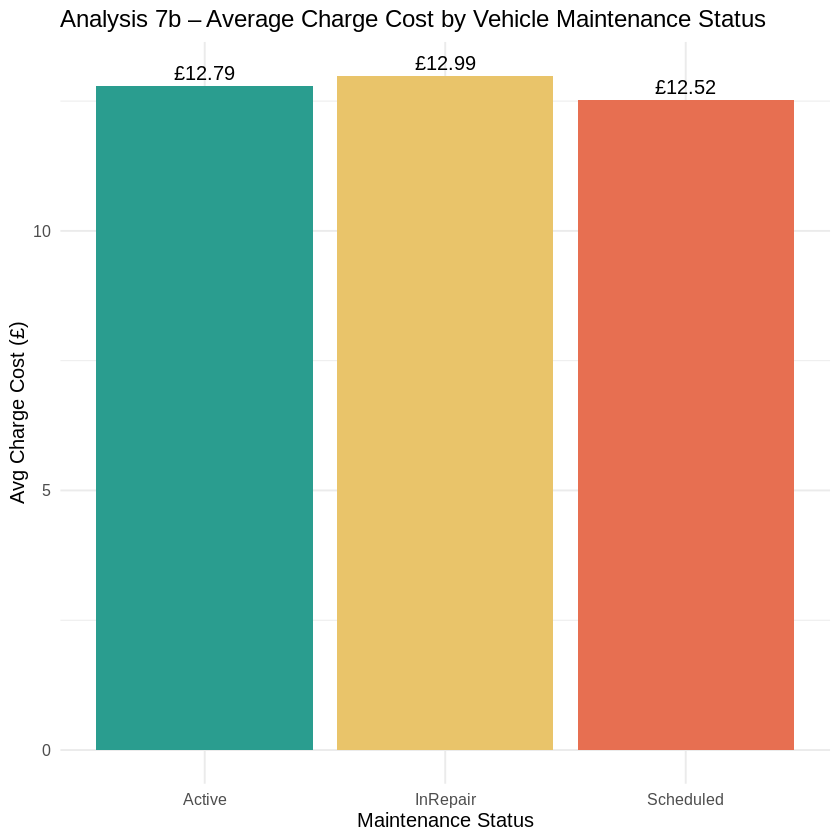

In [ ]:
# ANALYSIS 7 – Vehicle Battery Health vs Operational Cost

cat("=== ANALYSIS 7: Battery Health vs Charge Cost ===\n")

vehicle_cost <- master %>%
  filter(!is.na(battery_health_pct), !is.na(fuel_or_charge_cost)) %>%
  group_by(vehicle_id, vehicle_type, maintenance_status, battery_health_pct) %>%
  summarise(
    deliveries      = n(),
    avg_charge_cost = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    total_cost      = round(sum(fuel_or_charge_cost,  na.rm = TRUE), 2),
    .groups = "drop"
  )

cat("Correlation: battery_health_pct vs avg_charge_cost =",
    round(cor(vehicle_cost$battery_health_pct, vehicle_cost$avg_charge_cost,
              use = "complete.obs"), 3), "\n\n")

ggplot(vehicle_cost, aes(x = battery_health_pct, y = avg_charge_cost,
                         colour = vehicle_type, size = deliveries)) +
  geom_point(alpha = 0.75) +
  geom_smooth(method = "lm", se = TRUE, colour = "grey30", linewidth = 0.8) +
  scale_colour_brewer(palette = "Dark2") +
  labs(title = "Analysis 7 – Battery Health (%) vs Average Charge Cost per Delivery",
       x = "Battery Health (%)", y = "Average Charge/Fuel Cost (£)",
       colour = "Vehicle Type", size = "# Deliveries") +
  theme_minimal(base_size = 12)

# Bar: average charge cost by maintenance status
vehicle_cost %>%
  group_by(maintenance_status) %>%
  summarise(avg_cost = round(mean(avg_charge_cost), 2), .groups = "drop") %>%
  ggplot(aes(x = maintenance_status, y = avg_cost, fill = maintenance_status)) +
  geom_col(show.legend = FALSE) +
  geom_text(aes(label = paste0("£", avg_cost)), vjust = -0.4) +
  scale_fill_manual(values = c("Active" = "#2a9d8f", "InRepair" = "#e9c46a", "Scheduled" = "#e76f51")) +
  labs(title = "Analysis 7b – Average Charge Cost by Vehicle Maintenance Status",
       x = "Maintenance Status", y = "Avg Charge Cost (£)") +
  theme_minimal(base_size = 12)

=== ANALYSIS 8: Complaint Resolution by Zone ===
# A tibble: 24 × 6
   pickup_zone severity count avg_resolution_days pct_unresolved
   <chr>       <chr>    <int>               <dbl>          <dbl>
 1 AIRPORT     High         3                11.3           33.3
 2 AIRPORT     Low          6                 5.2           50  
 3 AIRPORT     Medium      23                 7.2           26.1
 4 CENTRAL     High        14                12.5           28.6
 5 CENTRAL     Low          6                 6.5           33.3
 6 CENTRAL     Medium      22                 5.5           18.2
 7 CTR         High         5                12.8           60  
 8 CTR         Low          5                 6.4           80  
 9 CTR         Medium       8                 6.6           25  
10 EAST        High        12                12.2           25  
# ℹ 14 more rows
# ℹ 1 more variable: avg_compensation <dbl>

=== All R Analytics complete. ===


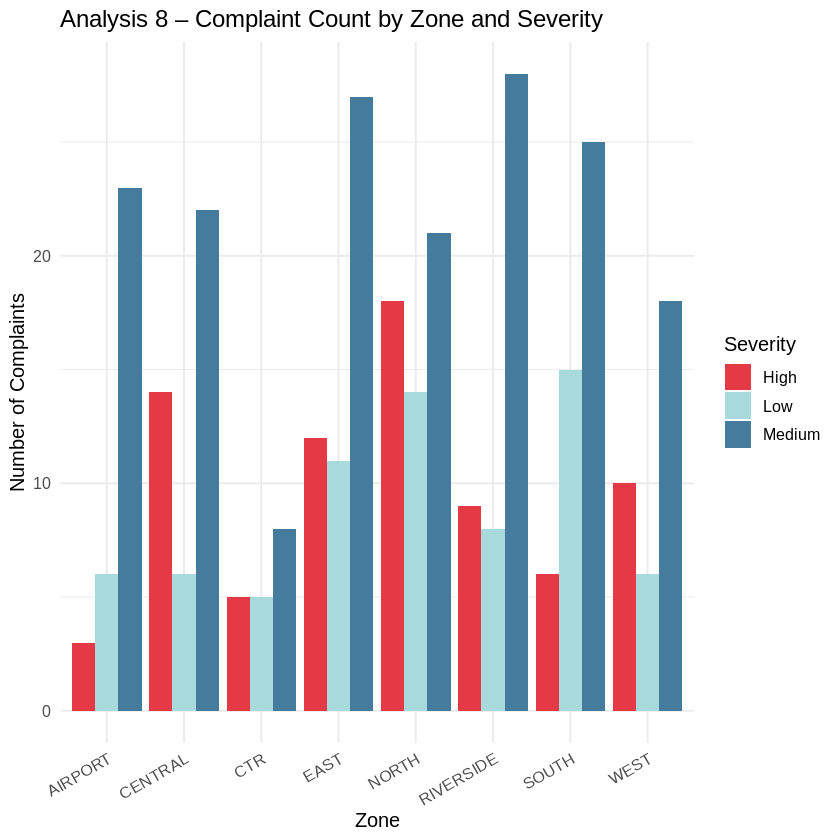

In [ ]:
# ANALYSIS 8 – Complaint Severity and Resolution Time by Zone

cat("=== ANALYSIS 8: Complaint Resolution by Zone ===\n")

complaint_zone <- complaints %>%
  left_join(orders %>% select(order_id, pickup_zone), by = "order_id") %>%
  filter(!is.na(pickup_zone)) %>%
  group_by(pickup_zone, severity) %>%
  summarise(
    count              = n(),
    avg_resolution_days = round(mean(resolution_days, na.rm = TRUE), 1),
    pct_unresolved      = round(100 * mean(status %in% c("Open","Escalated")), 1),
    avg_compensation    = round(mean(compensation_amount, na.rm = TRUE), 2),
    .groups = "drop"
  )

print(complaint_zone)

# Grouped bar: complaint count by zone and severity
ggplot(complaint_zone, aes(x = pickup_zone, y = count, fill = severity)) +
  geom_col(position = "dodge") +
  scale_fill_manual(values = c("Low"      = "#a8dadc",
                               "Medium"   = "#457b9d",
                               "High"     = "#e63946",
                               "Critical" = "#6d2b3d")) +
  labs(title = "Analysis 8 – Complaint Count by Zone and Severity",
       x = "Zone", y = "Number of Complaints", fill = "Severity") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

cat("\n=== All R Analytics complete. ===\n")